QUESTION: ACME Insurance Inc. offers affordable health insurance to thousands of customer all over the United States. As the lead data scientist at ACME, you're tasked with creating an automated system to estimate the annual medical expenditure for new customers, using information such as their age, sex, BMI, children, smoking habits and region of residence.

Estimates from your system will be used to determine the annual insurance premium (amount paid every month) offered to the customer. Due to regulatory requirements, you must be able to explain why your system outputs a certain prediction.

You're given a CSV file "medical-charges.csv" containing verified historical data, consisting of the aforementioned information and the actual medical charges incurred by over 1300 customers.

In [1]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
%matplotlib inline 
# This keeps the output inside the jupyeter notebook only not on the pop up window as once pop up gone output will also be gone.

The following settings will improve the default style and font sizes for our charts.

In [2]:
# sns.set_style('darkgrid')
# matplotlib.rcParams['font.size'] = 14
# matplotlib.rcParams['figure.figsize'] = (9, 6)
# matplotlib.rcParams['figure.facecolor'] = '#00000000'

In [3]:
# Following code sets the defaults params

# import matplotlib as mpl

# mpl.rcParams.update(mpl.rcParamsDefault)
# sns.reset_defaults()

In [4]:
# Fetching the downloaded csv data from the system
medical_df_direct = pd.read_csv('medical-charges.csv')
medical_df_direct.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


### Download the data using the **urlretrieve** function from **urllib.request**

In [5]:
# medical_charges_url = 'https://github.com/SurajChauhan76/Data-Warehouse/blob/main/medical-charges.csv' # This url does not work as its the webpage url not the raw data url, urlretrieve needs raw data url.

medical_charges_url = 'https://raw.githubusercontent.com/SurajChauhan76/Data-Warehouse/main/medical-charges.csv'
# "raw.githubusercontent.com": serves the actual file content.

from urllib.request import urlretrieve

urlretrieve(medical_charges_url, 'medical.csv')

('medical.csv', <http.client.HTTPMessage at 0x14be303b250>)

In [6]:
# Now create a Pandas dataframe using the downloaded file, to view and analyze the data
medical_df = pd.read_csv('medical.csv')
medical_df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [7]:
#  Check the data type for each column
medical_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [8]:
# Get the statistics of the numerical columns
medical_df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


## Exploratory Analysis and Visualization
Let's explore the data by visualizing the distribution of values in some columns of the dataset, and the relationships between "charges" and other column

Age:
Age is a numeric column. The minimum age in the dataset is 18 and the maximum age is 64. Thus, we can visualize the distribution of age using a histogram with 47 bins (one for each year) and a box plot. We'll use plotly to make the chart interactive, but you can create similar charts using Seaborn.

In [9]:
medical_df.age.describe()

count    1338.000000
mean       39.207025
std        14.049960
min        18.000000
25%        27.000000
50%        39.000000
75%        51.000000
max        64.000000
Name: age, dtype: float64

In [10]:
fig = px.histogram(medical_df, x='age', nbins=47, marginal='box', title='Distribution of Age')
fig.update_layout(bargap=0.1)
fig.show()

The distribution of ages in the dataset is almost uniform, with 20-30 customers at every age, except for the ages 18 and 19, which seem to have over twice as many customers as other ages. The uniform distribution might arise from the fact that there isn't a big variation in the number of people of any given age (between 18 & 64) in the USA.

## Body Mass Index
Let's look at the distribution of BMI (Body Mass Index) of customers, using a histogram and box plot.m

In [11]:
fig = px.histogram(medical_df, x='bmi', marginal='box', color_discrete_sequence=['red'], title='Distribution of BMI (Body Mass Index)')
fig.update_layout(bargap=0.1)
fig.show()

The measurements of body mass index seem to form a Gaussian distribution centered around the value 30, with a few outliers towards the right.

## Charges
Let's visualize the distribution of "charges" i.e. the annual medical charges for customers. This is the column we're trying to predict. Let's also use the categorical column "smoker" to distinguish the charges for smokers and non-smokers.

In [12]:
fig = px.histogram(medical_df, x='charges', marginal='box', color='smoker', color_discrete_sequence=['green', 'grey'], title='Annual Medical Charges')
fig.update_layout(bargap=0.1)
fig.show()

We can make the following observations from the above graph:
- For most customers, the annual medical charges are under $10,000. Only a small fraction of customer have higher medical expenses, possibly due to accidents, major illnesses and genetic diseases. The distribution follows a "power law".

- There is a significant difference in medical expenses between smokers and non-smokers. While the median for non-smokers is $7300, the median for smokers is close to $35,000.

## Smoker
Let's visualize the distribution of the "smoker" column (containing values "yes" and "no") using a histogram.

In [13]:
medical_df.smoker.value_counts()

smoker
no     1064
yes     274
Name: count, dtype: int64

In [14]:
fig = px.histogram(medical_df, x='smoker', color='sex', title='Smoker')
fig.show()

# px.histogram(medical_df, x='smoker', color='sex', title='Smoker') # This directly plots the chart.

It appears that 20% of customers have reported that they smoke. We can also see that smoking appears a more common habit among males. 

### Age and Charges

Let's visualize the relationship between "age" and "charges" using a scatter plot. Each point in the scatter plot represents one customer. We'll also use values in the "smoker" column to color the points.

In [15]:
fig = px.scatter(medical_df, x='age', y='charges', color='smoker', opacity=0.6, hover_data=['sex'], title='Age vs. Charges')
fig.update_traces(marker_size=5)
fig.show()

We can make the following observations from the above chart:
- The general trend seems to be that medical charges increase with age, as we might expect. However, there is significant variation at every age, and it's clear that age alone cannot be used to accurately determine medical charges.
- We can see three "clusters" of points, each of which seems to form a line with an increasing slope:

1. The first and the largest cluster consists primary of presumably "healthy non-smokers" who have relatively low medical charges compared to others
2. The second cluster contains a mix of smokers and non-smokers. It's possible that these are actually two distinct but overlapping clusters: "non-smokers with medical issues" and "smokers without major medical issues".
3. The final cluster consists exclusively of smokers, presumably smokers with major medical issues that are possibly related to or worsened by smoking.

## BMI and Changes

In [16]:
fig = px.scatter(medical_df, x='bmi', y='charges', color='smoker', hover_data=['sex'], opacity=0.6, title='BMI vs. Charges')
fig.update_traces(marker_size=5)
fig.show()

It appears that for non-smokers, an increase in BMI doesn't seem to be related to an increase in medical charges. However, medical charges seem to be significantly higher for smokers with a BMI greater than 30.

## Correlation

In [17]:
medical_df.charges.corr(medical_df.age)

np.float64(0.29900819333064765)

In [18]:
medical_df.corr(numeric_only=True)

,age,bmi,children,charges
age,1.000000,0.109272,0.042469,0.299008
bmi,0.109272,1.000000,0.012759,0.198341
children,0.042469,0.012759,1.000000,0.067998
charges,0.299008,0.198341,0.067998,1.000000


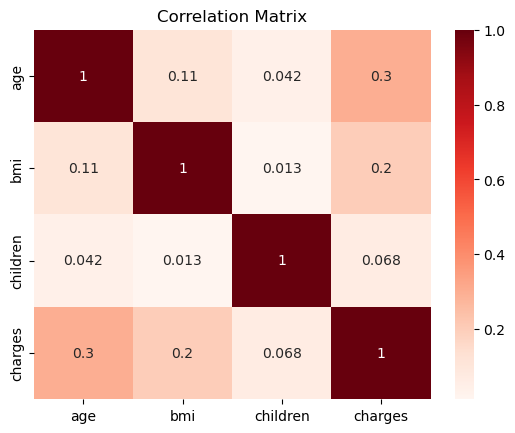

In [19]:
sns.heatmap(medical_df.corr(numeric_only=True), cmap='Reds', annot=True)
plt.title('Correlation Matrix')
plt.show()

## Linear Regression using Scikit-learn

Let's use the **LinearRegression** class from scikit-learn to find the best fit line for "age" vs. "charges" using the **ordinary least squares optimization technique**.

In [20]:
non_smoker_df = medical_df[medical_df.smoker == 'no']
non_smoker_df.head()

,age,sex,bmi,children,smoker,region,charges
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
5,31,female,25.740,0,no,southeast,3756.62160


In [21]:
# Fucntion to calculate loss
def rmse(targets, predictions):
    return np.sqrt(np.mean(np.square(targets - predictions)))

In [22]:
from sklearn.linear_model import LinearRegression

In [23]:
# Create a new model object
model = LinearRegression()

In [24]:
help(model.fit)

Help on method fit in module sklearn.linear_model._base:

fit(X, y, sample_weight=None) method of sklearn.linear_model._base.LinearRegression instance
    Fit linear model.

    Parameters
    ----------
    X : {array-like, sparse matrix} of shape (n_samples, n_features)
        Training data.

    y : array-like of shape (n_samples,) or (n_samples, n_targets)
        Target values. Will be cast to X's dtype if necessary.

    sample_weight : array-like of shape (n_samples,), default=None
        Individual weights for each sample.

        .. versionadded:: 0.17
           parameter *sample_weight* support to LinearRegression.

    Returns
    -------
    self : object
        Fitted Estimator.



help() helps to identify the type of inputs and targets to be given to model.fit. Here the input X must be a 2-d array, so we'll need to pass a dataframe, instead of a single column.

In [25]:
inputs = non_smoker_df[['age']]
targets = non_smoker_df['charges']  # non_smoker_df.charges
print('inputs shape:', inputs.shape)
print('targets shape:', targets.shape)

inputs shape: (1064, 1)
targets shape: (1064,)


In [26]:
model.fit(inputs, targets)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [27]:
# Now lets predict the charges using the model:
predictions = model.predict(inputs)
predictions

array([2719.0598744 , 5391.54900271, 6727.79356686, ..., 2719.0598744 ,
       2719.0598744 , 3520.80661289])

In [28]:
non_smoker_df[['age', 'charges']].head()

,age,charges
1,18,1725.55230
2,28,4449.46200
3,33,21984.47061
4,32,3866.85520
5,31,3756.62160


In [29]:
# Now lets calculate the loss:
print('Loss: ', rmse(targets, predictions))

Loss:  4662.505766636395


Seems like our prediction is off by $4000 on average, which is not too bad considering the fact that there are several outliers.

The parameters of the model are stored in the `coef_` and `intercept_` properties.

In [30]:
# weight
weight = model.coef_

bias = model.intercept_

print(f'Weight: {weight}\nBias: {bias}')

Weight: [267.24891283]
Bias: -2091.4205565650827


Lets visualize the model:

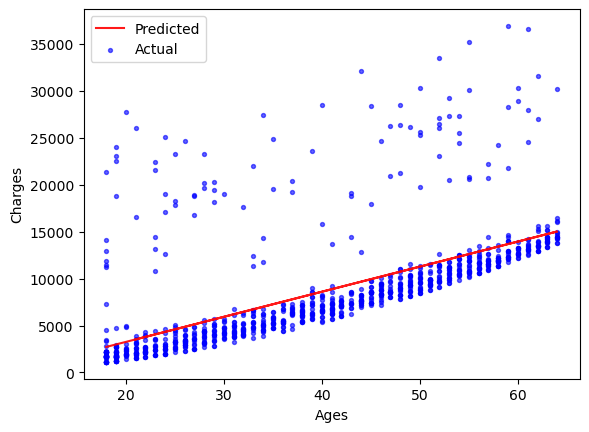

In [31]:
ages = non_smoker_df.age  # Here ages is series
targets = non_smoker_df.charges
# predictions = model.predict(ages) # Throws error as it expects a 2D array and a series of ages
predictions = model.predict(non_smoker_df[['age']])

# Line plot for model predictions
plt.plot(ages, predictions, 'r', alpha=0.9)
# Scatter plot for actual charges
plt.scatter(ages, targets, c='blue', s=8, alpha=0.6)
plt.xlabel('Ages')
plt.ylabel('Charges')
plt.legend(['Predicted', 'Actual'])
plt.show()

Use the **SGDRegressor class** from scikit-learn to train a model using the **stochastic gradient descent technique**. Make predictions and compute the loss.

In [32]:
from sklearn.linear_model import SGDRegressor

In [33]:
model2 = SGDRegressor()

In [34]:
model2.fit(inputs, targets)

,loss,'squared_error'
,penalty,'l2'
,alpha,0.0001
,l1_ratio,0.15
,fit_intercept,True
,max_iter,1000
,tol,0.001
,shuffle,True
,verbose,0
,epsilon,0.1
,random_state,None


In [35]:
# Make predictions
predictions2 = model2.predict(inputs)
predictions2

array([-177.93688672, 3025.28317704, 4626.89320892, ..., -177.93688672,
       -177.93688672,  783.02913241])

In [36]:
# Check the weight and bias
weight = model2.coef_

bias = model2.intercept_

print(f'Weight: {weight}\nBias: {bias}')

Weight: [320.32200638]
Bias: [-5943.73300149]


In [37]:
# Calucate the loss:
loss1 = rmse(targets, predictions)
loss2 = rmse(targets, predictions2)
print('Model1 Loss:', loss1)
print('Model2 Loss:', loss2)

Model1 Loss: 4662.505766636395
Model2 Loss: 5040.019678213341


## Linear Regression using Multiple Features

So far, we've used on the "age" feature to estimate "charges". Adding another feature like "bmi" is fairly straightforward. We simply assume the following relationship:


We need to change just one line of code to include the BMI.

In [38]:
# Create inputs and targets
inputs, targets = non_smoker_df[['age', 'bmi']], non_smoker_df['charges']

# # Create and train the model
model = LinearRegression().fit(inputs, targets)

# Generate predictions
predictions = model.predict(inputs)

# Compute loss to evalute the model
loss = rmse(targets, predictions)
print('Loss:', loss)

Loss: 4662.3128354612945


As you can see, adding the BMI doesn't seem to reduce the loss by much, as the BMI has a very weak correlation with charges, especially for non smokers.

In [39]:
non_smoker_df.charges.corr(non_smoker_df.bmi)

np.float64(0.08403654312833272)

### Visualize the relationship between all 3 variables "age", "bmi" and "charges" using a 3D scatter plot.

In [40]:
fig = px.scatter_3d(non_smoker_df, x='age', y='bmi', z='charges', hover_data=['sex'])
fig.update_traces(marker_size=5, marker_opacity=0.5)
fig.show()

You can see that it's harder to interpret a 3D scatter plot compared to a 2D scatter plot. As we add more features, it becomes impossible to visualize all feature at once, which is why we use measures like correlation and loss.

#### Check the parameters of the model

In [41]:
model.coef_, model.intercept_

(array([266.87657817,   7.07547666]), np.float64(-2293.6320906488672))

Clearly, BMI has a much lower weightage, and you can see why. It has a tiny contribution, and even that is probably accidental. This is an important thing to keep in mind: you can't find a relationship that doesn't exist, no matter what machine learning technique or optimization algorithm you apply.

#### Let's go one step further, and add the final numeric column: "children", which seems to have some correlation with "charges".

$charges = w_1 \times age + w_2 \times bmi + w_3 \times charges + b$

In [42]:
# Create inputs and targets
inputs, targets = non_smoker_df[['age', 'bmi', 'children']], non_smoker_df['charges']

# # Create and train the model
model = LinearRegression().fit(inputs, targets)

# Generate predictions
predictions = model.predict(inputs)

# Compute loss to evalute the model
loss = rmse(targets, predictions)
print('Loss:', loss)

Loss: 4608.470405038246


Once again, we don't see a big reduction in the loss, even though it's greater than in the case of BMI.

## Creating the model on the Complete set of data - medical_df

In [43]:
# Create inputs and targets
inputs, targets = medical_df[['age', 'bmi', 'children']], medical_df['charges']

# # Create and train the model
model = LinearRegression().fit(inputs, targets)

# Generate predictions
predictions = model.predict(inputs)

# Compute loss to evalute the model
loss = rmse(targets, predictions)
print('Loss:', loss)

Loss: 11355.317901125973


Since medical_df contains both smokers and non-smokers and hence the loss has been increased greatly indicating its not a good model.

## Using Categorical Features for Machine Learning
So far we've been using only numeric columns, since we can only perform computations with numbers. If we could use categorical columns like "smoker", we can train a single model for the entire dataset.

To use the categorical columns, we simply need to convert them to numbers. There are three common techniques for doing this:

- If a categorical column has just two categories (it's called a binary category), then we can replace their values with 0 and 1.
- If a categorical column has more than 2 categories, we can perform one-hot encoding i.e. create a new column for each category with 1s and 0s.
- If the categories have a natural order (e.g. cold, neutral, warm, hot), then they can be converted to numbers (e.g. 1, 2, 3, 4) preserving the order. These are called ordinals

### Binary Categories
The "smoker" category has just two values "yes" and "no". Let's create a new column "smoker_code" containing 0 for "no" and 1 for "yes".

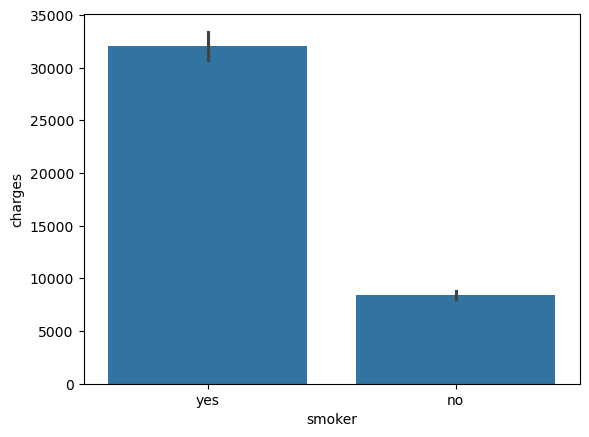

In [44]:
sns.barplot(medical_df, x='smoker', y='charges')
plt.show()

In [45]:
smoker_code = {'yes':1, 'no':0}

medical_df['smoker_code'] = medical_df.smoker.map(smoker_code)
medical_df.head()

,age,sex,bmi,children,smoker,region,charges,smoker_code
0,19,female,27.900,0,yes,southwest,16884.92400,1
1,18,male,33.770,1,no,southeast,1725.55230,0
2,28,male,33.000,3,no,southeast,4449.46200,0
3,33,male,22.705,0,no,northwest,21984.47061,0
4,32,male,28.880,0,no,northwest,3866.85520,0


In [46]:
# Correlation between charges and smoker_code
medical_df.charges.corr(medical_df.smoker_code)

np.float64(0.7872514304984772)

Here smoker_code has strong correlation with the medical chagers.

We can now use the `smoker_df` column for linear regression.

$charges = w_1 \times age + w_2 \times bmi + w_3 \times children + w_4 \times smoker_code + b$

In [47]:
# Create inputs and targets
inputs, targets = medical_df[['age', 'bmi', 'children', 'smoker_code']], medical_df['charges']

# Create and trian the model
model = LinearRegression().fit(inputs, targets)

# Make predictions
predictions = model.predict(inputs)

# Compute the loss
loss = rmse(targets, predictions)
print('Loss', loss)

Loss 6056.439217188081


The loss reduces from 11355 to 6056, almost by 50%! This is an important lesson: **never ignore categorical data**.

### Add sex data

In [48]:
sex_code = {'male':1, 'female':0}
medical_df['sex_code'] = medical_df.sex.map(sex_code)
medical_df.head()

,age,sex,bmi,children,smoker,region,charges,smoker_code,sex_code
0,19,female,27.900,0,yes,southwest,16884.92400,1,0
1,18,male,33.770,1,no,southeast,1725.55230,0,1
2,28,male,33.000,3,no,southeast,4449.46200,0,1
3,33,male,22.705,0,no,northwest,21984.47061,0,1
4,32,male,28.880,0,no,northwest,3866.85520,0,1


In [49]:
# Create inputs and targets
inputs, targets = medical_df[['age', 'bmi', 'children', 'smoker_code', 'sex_code']], medical_df['charges']

# Create and trian the model
model = LinearRegression().fit(inputs, targets)

# Make predictions
predictions = model.predict(inputs)

# Compute the loss
loss = rmse(targets, predictions)
print('Loss', loss)

Loss 6056.100708754546


Here sex has insignificant reduction on the loss. 

### One-hot Encoding

The "region" column contains 4 values, so we'll need to use hot encoding and create a new column for each region.

![](https://i.imgur.com/n8GuiOO.png)


In [50]:
from sklearn import preprocessing
enc = preprocessing.OneHotEncoder()
enc.fit(medical_df[['region']])
oneHot = enc.transform(medical_df[['region']]).toarray()

print(enc.categories_)
print(oneHot)

[array(['northeast', 'northwest', 'southeast', 'southwest'], dtype=object)]
[[0. 0. 0. 1.]
 [0. 0. 1. 0.]
 [0. 0. 1. 0.]
 ...
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]
 [0. 1. 0. 0.]]


In [51]:
# Add the region codes to the df
medical_df[['northeast', 'northwest', 'southeast', 'southwest']] = oneHot
medical_df.head()

,age,sex,bmi,children,smoker,region,charges,smoker_code,sex_code,northeast,northwest,southeast,southwest
0,19,female,27.900,0,yes,southwest,16884.92400,1,0,0.0,0.0,0.0,1.0
1,18,male,33.770,1,no,southeast,1725.55230,0,1,0.0,0.0,1.0,0.0
2,28,male,33.000,3,no,southeast,4449.46200,0,1,0.0,0.0,1.0,0.0
3,33,male,22.705,0,no,northwest,21984.47061,0,1,0.0,1.0,0.0,0.0
4,32,male,28.880,0,no,northwest,3866.85520,0,1,0.0,1.0,0.0,0.0


### Add region columns in the model prediction

In [52]:
# Create inputs and targets
input_cols = ['age', 'bmi', 'children', 'smoker_code', 'sex_code', 'northeast', 'northwest', 'southeast', 'southwest']
inputs, targets = medical_df[input_cols], medical_df['charges']

# Create and trian the model
model = LinearRegression().fit(inputs, targets)

# Make predictions
predictions = model.predict(inputs)

# Compute the loss
loss = rmse(targets, predictions)
print('Loss', loss)

Loss 6041.6796511744515


Once again, this leads to a fairly small reduction in the loss.

## Model Improvements

Let's discuss and apply some more improvements to our model.

### Feature Scaling

Recall that due to regulatory requirements, we also need to explain the rationale behind the predictions our model. 

$charges = w_1 \times age + w_2 \times bmi + w_3 \times charges + w_4 \times smoker + w_5 \times sex + w_6 \times region + b$

To compare the importance of each feature in the model, our first instinct might be to compare their weights. 

In [53]:
print(f'Weights: {model.coef_}\nIntercept: {model.intercept_}')

Weights: [  256.85635254   339.19345361   475.50054515 23848.53454191
  -131.3143594    587.00923503   234.0453356   -448.01281436
  -373.04175627]
Intercept: -12525.547811195462


Create a dataframe for features and its weights also include base intercept as 1

In [54]:
weights_df = pd.DataFrame({
    'feature': np.append(input_cols, 1),
    'weight': np.append(model.coef_, model.intercept_)
})
weights_df

,feature,weight
0,age,256.856353
1,bmi,339.193454
2,children,475.500545
3,smoker_code,23848.534542
4,sex_code,-131.314359
5,northeast,587.009235
6,northwest,234.045336
7,southeast,-448.012814
8,southwest,-373.041756
9,1,-12525.547811


If a person is charged for the medical premium then he might ask on what basis he got has been charged so much then these weight parameters are useful in explaining those charges.
If age=30 then as per age weight age charge = 30 * 256.856353 and so on and the sum total is the medical charges for the premium.

While it seems like BMI and the "northeast" have a higher weight than age, keep in mind that the range of values for BMI is limited (15 to 40) and the "northeast" column only takes the values 0 and 1.

Because different columns have different ranges, we run into two issues:

1. We can't compare the weights of different column to identify which features are important
2. A column with a larger range of inputs may disproportionately affect the loss and dominate the optimization process.

For this reason, it's common practice to scale (or standardize) the values in numeric column by subtracting the mean and dividing by the standard deviation.

![](https://i.imgur.com/dT5fLFI.png)

We can apply scaling using the StandardScaler class from `scikit-learn`.

In [55]:
from sklearn.preprocessing import StandardScaler

In [56]:
numeric_cols = ['age', 'bmi', 'children']
scaler = StandardScaler()
scaler.fit(medical_df[numeric_cols])

print(f'Scaler mean: {scaler.mean_}')
print(f'Scaler variance: {scaler.var_}')

# Scale the data
scaled_inputs = scaler.transform(medical_df[numeric_cols])
print(f'Scaled inputs: {scaled_inputs}')

Scaler mean: [39.20702541 30.66339686  1.09491779]
Scaler variance: [197.25385199  37.16008997   1.45212664]
Scaled inputs: [[-1.43876426 -0.45332    -0.90861367]
 [-1.50996545  0.5096211  -0.07876719]
 [-0.79795355  0.38330685  1.58092576]
 ...
 [-1.50996545  1.0148781  -0.90861367]
 [-1.29636188 -0.79781341 -0.90861367]
 [ 1.55168573 -0.26138796 -0.90861367]]


In [57]:
# Combine the scaled inputs with categorical data for inputs and create model and trian
cat_cols = ['smoker_code', 'sex_code', 'northeast', 'northwest', 'southeast', 'southwest']
categorical_data = medical_df[cat_cols].values

inputs = np.concatenate((scaled_inputs, categorical_data), axis=1) # inputs must be a 2D array or else throws error
targets = medical_df.charges

# Create and train the model
model = LinearRegression().fit(inputs, targets)

# Generate predictions
predictions = model.predict(inputs)

# Compute the loss to evaluate the model
loss = rmse(targets, predictions)
print('Loss:', loss)

Loss: 6041.6796511744515


rmse is a manually defined function to calucalte the loss.
    
Use "mean_squared_error" from sklearn.metrics to calculate "sme" and give parameter "squared=False" to get the rmse

#### import the upgraded version of scikit-lean or else squared=False throws error
!pip install --upgrade scikit-learn

import sklearn

print(sklearn.__version__)

In [58]:
from sklearn.metrics import mean_squared_error

rmse_loss = np.sqrt(mean_squared_error(targets, predictions))
print(f'Loss: {rmse_loss}')

Loss: 6041.6796511744515


Now create weight dataframe using scaled features and compare with previous weights

In [59]:
weights_df = pd.DataFrame({
    'feature': np.append(numeric_cols + cat_cols, 1),
    'weight': np.append(model.coef_, model.intercept_)
})
weights_df.sort_values('weight', ascending=False)

,feature,weight
3,smoker_code,23848.534542
9,1,8466.483215
0,age,3607.472736
1,bmi,2067.691966
5,northeast,587.009235
2,children,572.998210
6,northwest,234.045336
4,sex_code,-131.314359
8,southwest,-373.041756
7,southeast,-448.012814


The most important feature are:

1. Smoker
2. Age
3. BMI

## Creating a Test Set
Models like the one we've created in this tutorial are designed to be used in the real world. It's common practice to set aside a small fraction of the data (e.g. 20%) just for testing and reporting the results of the model.

In [61]:
from sklearn.model_selection import train_test_split

inputs_train, inputs_test, targets_train, targets_test = train_test_split(inputs, targets, test_size=0.2)

In [64]:
# Create and train the model
model = LinearRegression().fit(inputs_train, targets_train)

# Make predictions
predictions_test = model.predict(inputs_test)

# Compute the loss for test data
rmse_test_loss = np.sqrt(mean_squared_error(targets_test, predictions_test))
print("Test loss:", rmse_loss)

# Compute the loss for train data
predictions_train = model.predict(inputs_train)
rmse_train_loss = np.sqrt(mean_squared_error(targets_train, predictions_train))
print("Training loss:", rmse_train_loss)

Test loss: 5961.867625126136
Training loss: 6071.538700753207


### How to Approach a Machine Learning Problem

Here's a strategy you can apply to approach any machine learning problem:

1. Explore the data and find correlations between inputs and targets
2. Pick the right model, loss functions and optimizer for the problem at hand
3. Scale numeric variables and one-hot encode categorical data
4. Set aside a test set (using a fraction of the training set)
5. Train the model
6. Make predictions on the test set and compute the loss

#### Ways to delete a column from df
1. del df['column_name']
2. df.drop('column_name', axis=1, inplace=True)

### Difference between fit(), transform(), fit_transform()
🔧 fit(): Learn from data
- Purpose: Computes and stores internal parameters based on the input data.
- Used by: Scalers, encoders, models, etc.
- Does not return transformed data — just prepares the object.
✅ Example:
scaler.fit(X_train)  # Learns mean and std from training data

🔄 transform(): Apply learned parameters
- Purpose: Uses the parameters learned during fit() to transform the data.
- Requires: That fit() has already been called.
- Returns: Transformed data.
✅ Example:
X_scaled = scaler.transform(X_test)  # Applies scaling using training stats

⚡ fit_transform(): Do both in one step
- Purpose: Combines fit() and transform() into a single call.
- Used when: You want to learn from and transform the same dataset.
- Returns: Transformed data.
✅ Example:
X_train_scaled = scaler.fit_transform(X_train)  # Learns and applies scaling

🧠 When to use what?
- fit_transform() : Preprocessing training data 
- transform() : Preprocessing test/validation data
- fit() : Training a model


#### Use LabelEncoder and OrdinalEncoder for encoding categorical data instead of oneHot encoding

In [67]:
medical_df.head()

,age,sex,bmi,children,smoker,region,charges,smoker_code,sex_code,northeast,northwest,southeast,southwest
0,19,female,27.900,0,yes,southwest,16884.92400,1,0,0.0,0.0,0.0,1.0
1,18,male,33.770,1,no,southeast,1725.55230,0,1,0.0,0.0,1.0,0.0
2,28,male,33.000,3,no,southeast,4449.46200,0,1,0.0,0.0,1.0,0.0
3,33,male,22.705,0,no,northwest,21984.47061,0,1,0.0,1.0,0.0,0.0
4,32,male,28.880,0,no,northwest,3866.85520,0,1,0.0,1.0,0.0,0.0


In [76]:
mdcl_df = medical_df[['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']]
mdcl2_df = mdcl_df.copy()
mdcl_df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [77]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
# LabelEncoder is designed for one column at a time, not multiple.
mdcl_df['sex_encoded'] = le.fit_transform(mdcl_df['sex'])
mdcl_df['smoker_encoded'] = le.fit_transform(mdcl_df['smoker'])
mdcl_df['region_encoded'] = le.fit_transform(mdcl_df['region'])

mdcl_df.head()

C:\Users\suraj\AppData\Local\Temp\ipykernel_16840\3020225075.py:5: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\suraj\AppData\Local\Temp\ipykernel_16840\3020225075.py:6: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\suraj\AppData\Local\Temp\ipykernel_16840\3020225075.py:7: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/panda

,age,sex,bmi,children,smoker,region,charges,sex_encoded,smoker_encoded,region_encoded
0,19,female,27.900,0,yes,southwest,16884.92400,0,1,3
1,18,male,33.770,1,no,southeast,1725.55230,1,0,2
2,28,male,33.000,3,no,southeast,4449.46200,1,0,2
3,33,male,22.705,0,no,northwest,21984.47061,1,0,1
4,32,male,28.880,0,no,northwest,3866.85520,1,0,1


In [78]:
mdcl2_df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [81]:
from sklearn.preprocessing import OrdinalEncoder
# OrdinalEncoder is designed for multiple categorical columns at a time for encoding.

oe = OrdinalEncoder()
mdcl2_df[['sex_encoded', 'smoker_encoded', 'region_encoded']] = oe.fit_transform(mdcl_df[['sex', 'smoker', 'region']])

mdcl2_df.head()

,age,sex,bmi,children,smoker,region,charges,sex_encoded,smoker_encoded,region_encoded
0,19,female,27.900,0,yes,southwest,16884.92400,0.0,1.0,3.0
1,18,male,33.770,1,no,southeast,1725.55230,1.0,0.0,2.0
2,28,male,33.000,3,no,southeast,4449.46200,1.0,0.0,2.0
3,33,male,22.705,0,no,northwest,21984.47061,1.0,0.0,1.0
4,32,male,28.880,0,no,northwest,3866.85520,1.0,0.0,1.0


#### Apply scaling and test split along with creating and training the model

In [84]:
# Tools for preprocessing data
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Tool for model creation and trainig
from sklearn.linear_model import LinearRegression

# Tool for loss metrics calculation
from sklearn.metrics import mean_squared_error, r2_score

# Preprocess the data
inputs = mdcl2_df[['age', 'sex_encoded', 'bmi', 'children', 'smoker_encoded', 'region_encoded']]
targets = mdcl2_df.charges
inputs_train, inputs_test, targets_train, targets_test = train_test_split(inputs, targets, test_size=0.2)

# Scale the numeric cols
scaler = StandardScaler()
inputs_train_scaled = scaler.fit_transform(inputs_train)
inputs_test_scaled = scaler.transform(inputs_test)

# Create and train the model
model = LinearRegression().fit(inputs_train_scaled, targets_train)

# Generate predictions
predictions_test = model.predict(inputs_test_scaled)
predictions_train = model.predict(inputs_train_scaled)

# Compute the loss
loss_test = np.sqrt(mean_squared_error(targets_test, predictions_test))
r2_test = r2_score(targets_test, predictions_test)
loss_train = np.sqrt(mean_squared_error(targets_train, predictions_train))
r2_train = r2_score(targets_train, predictions_train)

print(f'Test loss: {loss_test}\nTest - variance in target(r2_score): {r2_test}')
print(f'\nTraining loss: {loss_train}\nTraining - variance in target(r2_score): {r2_train}')

Test loss: 6572.399251229496
Test - variance in target(r2_score): 0.7022437195624756

Training loss: 5912.725303186989
Training - variance in target(r2_score): 0.761963109391658


Here Test loss is more than the Training loss as the model has not seen the test data and hence its loss would be more compared to training.

- r2_score: Indicates how well your model explains variance in the target (1.0 is perfect).
- r2: Closer to 1 means better fit.

## Summary and Further Reading
We've covered the following topics in this tutorial:

- A typical problem statement for machine learning
- Downloading and exploring a dataset for machine learning
- Linear regression with one variable using Scikit-learn
- Linear regression with multiple variables
- Using categorical features for machine learning
- Regression coefficients and feature importance
- Creating a training and test set for reporting results